<a href="https://colab.research.google.com/github/karanamsubbarao/llm-course/blob/main/LLM_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Section 1 : Model Parameters : Inference Memory Requirements (16 points)**

**Task 1:   Parameter Census**

In [61]:
import pandas as mypd
from IPython.display import HTML

# Read Excel
df = mypd.read_excel("/content/Parameter-Census-Table.xlsx",na_filter=False)

# 2. Convert to an HTML table string
html_table = df.to_html(index=False, classes="table table-striped table-hover")

display(HTML(html_table))

Model,Layers (𝐿),𝑑model,Heads,𝑑ff,Vocab (𝑉),Max Seq (𝑇),Total Params
Small,12,768,12,3072,50257,1024,~124M
Medium,24,1024,16,4096,50257,1024,~355M
Large,36,1280,20,5120,50257,1024,~774M
XL,48,1600,25,6400,50257,1024,~1.5B
,,,,,,,
,,,,,,,
,,,,,,,
,,,,,,,
Component,Formula,Small (124M),Medium (355M),Large (774M),XL (1.5B),,
,,,,,,,


In [62]:
def get_input_embeddings(batch_size, sequence_length, dmodel) :
  return batch_size * sequence_length * dmodel

In [63]:
def get_Q_K_V_Projection(batch_size,sequence_length,dmodel) :
  return batch_size *3 * sequence_length * dmodel

In [64]:
def get_attention_Scores(batch_size,heads,sequence_length) :
  return batch_size * heads * sequence_length * sequence_length

In [65]:
def get_mlp_activations(batch_size, sequence_length, dff) :
  return batch_size * sequence_length * dff

In [66]:
def getLayerNorm(batch_size,sequence_Length,dmodel) :
  return batch_size *sequence_Length * dmodel

In [67]:
def get_total_activation_elements(batch_size, heads, sequence_length, dmodel,dff) :
  total_input_embeddings = get_input_embeddings(batch_size, sequence_length, dmodel);
  q_k_v_projections =  get_Q_K_V_Projection(batch_size,sequence_length,dmodel);
  attention_scores = get_attention_Scores(batch_size, heads,sequence_length);
  mlp_activations = get_mlp_activations(batch_size,sequence_length,dff);
  layer_norm = getLayerNorm(batch_size,sequence_length,dmodel);
  return total_input_embeddings + q_k_v_projections + attention_scores + mlp_activations + layer_norm

In [68]:
def get_peak_activation_memory_for_fp16(total_activation_elements):
  return total_activation_elements * 2

In [69]:
def get_peak_activation_memory_in_mb_for_fp16(total_activation_elements):
  return total_activation_elements * 2 /(1024 *1024)

In [70]:
def get_peak_activation_memory_for_fp32(total_activation_elements):
  return total_activation_elements * 4

In [71]:
def get_peak_activation_memory_in_mb_for_fp32(total_activation_elements):
  return total_activation_elements * 4 /(1024 * 1024)

In [72]:
def get_Parameter_Memory_for_fp16_in_mb(total_parameters,):
  return total_parameters * (10**6) * 2 / (1024 *1024)

In [73]:
def get_Parameter_Memory_for_fp32_in_mb(total_parameters):
  return total_parameters * (10**6) * 4 / (1024 *1024)

In [74]:
def get_activation_memory_parameter_memory_ratio_for_fp16(total_activation_elements,total_parameters):
  return get_peak_activation_memory_in_mb_for_fp16(total_activation_elements)/get_Parameter_Memory_for_fp16_in_mb(total_parameters)

In [75]:
def get_activation_memory_parameter_memory_ratio_for_fp32(total_activation_elements,total_parameters):
  return get_peak_activation_memory_in_mb_for_fp32(total_activation_elements)/get_Parameter_Memory_for_fp32_in_mb(total_parameters)

In [76]:
## GPT-2 Small
model_small = "GPT-2 Small"
total_layers_for_small = 12
dmodel_for_small = 768
heads_for_small = 12
dff_for_small = 3072
vocab_for_small = 50,257
max_seq_for_small = 1024
batch_size_for_small = 1
sequence_length_for_small = 1024
total_parameter_count_for_small= 124356864

total_activation_elements_for_small = get_total_activation_elements(batch_size_for_small,heads_for_small,sequence_length_for_small,dmodel_for_small,dff_for_small)
print('total_activation_elements_for_small',total_activation_elements_for_small)

peak_activation_memory_in_mb_for_small_for_fp16 = get_peak_activation_memory_in_mb_for_fp16(total_activation_elements_for_small)
print('peak_activation_memory_in_mb_for_small_for_fp16',peak_activation_memory_in_mb_for_small_for_fp16)

parameter_memory_in_mb_for_small_for_fp16 = get_Parameter_Memory_for_fp16_in_mb(total_activation_elements_for_small)
print('parameter_memory_in_mb_for_small_for_fp16',parameter_memory_in_mb_for_small_for_fp16)

peak_activation_memory_in_mb_for_small_for_fp32 = get_peak_activation_memory_in_mb_for_fp32(total_activation_elements_for_small)
print('peak_activation_memory_in_mb_for_small_for_fp32',peak_activation_memory_in_mb_for_small_for_fp32)

activation_memory_parameter_memory_ratio_for_fp16_for_small = get_activation_memory_parameter_memory_ratio_for_fp16(total_activation_elements_for_small,total_parameter_count_for_small)
print('activation_memory_parameter_memory_ratio_for_fp16_for_small',activation_memory_parameter_memory_ratio_for_fp16_for_small)

activation_memory_parameter_memory_ratio_for_fp32_for_small = get_activation_memory_parameter_memory_ratio_for_fp32(total_activation_elements_for_small,total_parameter_count_for_small)
print('activation_memory_parameter_memory_ratio_for_fp32_for_small',activation_memory_parameter_memory_ratio_for_fp32_for_small)

activation_memory_parameter_memory_ratio_for_fp16_for_small = get_activation_memory_parameter_memory_ratio_for_fp16(total_activation_elements_for_small,total_parameter_count_for_small)
print('activation_memory_parameter_memory_ratio_for_fp16_for_small',activation_memory_parameter_memory_ratio_for_fp16_for_small)

activation_memory_parameter_memory_ratio_for_fp32_for_small = get_activation_memory_parameter_memory_ratio_for_fp32(total_activation_elements_for_small,total_parameter_count_for_small)
print('activation_memory_parameter_memory_ratio_for_fp32_for_small',activation_memory_parameter_memory_ratio_for_fp32_for_small)


total_activation_elements_for_small 19660800
peak_activation_memory_in_mb_for_small_for_fp16 37.5
parameter_memory_in_mb_for_small_for_fp16 37500000.0
peak_activation_memory_in_mb_for_small_for_fp32 75.0
activation_memory_parameter_memory_ratio_for_fp16_for_small 1.5809983757711998e-07
activation_memory_parameter_memory_ratio_for_fp32_for_small 1.5809983757711998e-07
activation_memory_parameter_memory_ratio_for_fp16_for_small 1.5809983757711998e-07
activation_memory_parameter_memory_ratio_for_fp32_for_small 1.5809983757711998e-07


In [77]:
### Model GPT-2 Medium
model_medium = "GPT-2 Medium"
total_layers_for_medium = 24
dmodel_for_medium = 1024
heads_for_medium = 16
dff_for_medium = 4096
vocab_for_medium = 50257
max_seq_for_medium = 1024
batch_size_for_medium = 1
sequence_length_for_medium = 1024
total_parameter_count_for_medium= 354601984

total_activation_elements_for_medium = get_total_activation_elements(batch_size_for_medium,heads_for_medium,sequence_length_for_medium,dmodel_for_medium,dff_for_medium)
print('total_activation_elements_for_medium',total_activation_elements_for_medium)

peak_activation_memory_in_mb_for_medium_for_fp16 = get_peak_activation_memory_in_mb_for_fp16(total_activation_elements_for_medium)
print('peak_activation_memory_in_mb_for_medium_for_fp16',peak_activation_memory_in_mb_for_medium_for_fp16)

parameter_memory_in_mb_for_medium_for_fp16 = get_Parameter_Memory_for_fp16_in_mb(total_activation_elements_for_medium)
print('parameter_memory_in_mb_for_medium_for_fp16',parameter_memory_in_mb_for_medium_for_fp16)

peak_activation_memory_in_mb_for_medium_for_fp32 = get_peak_activation_memory_in_mb_for_fp32(total_activation_elements_for_medium)
print('peak_activation_memory_in_mb_for_medium_for_fp32',peak_activation_memory_in_mb_for_medium_for_fp32)

activation_memory_parameter_memory_ratio_for_fp16_for_medium = get_activation_memory_parameter_memory_ratio_for_fp16(total_activation_elements_for_medium,total_parameter_count_for_medium)
print('activation_memory_parameter_memory_ratio_for_fp16_for_medium',activation_memory_parameter_memory_ratio_for_fp16_for_medium)

activation_memory_parameter_memory_ratio_for_fp32_for_medium = get_activation_memory_parameter_memory_ratio_for_fp32(total_activation_elements_for_medium,total_parameter_count_for_medium)
print('activation_memory_parameter_memory_ratio_for_fp32_for_medium',activation_memory_parameter_memory_ratio_for_fp32_for_medium)

activation_memory_parameter_memory_ratio_for_fp16_for_medium = get_activation_memory_parameter_memory_ratio_for_fp16(total_activation_elements_for_medium,total_parameter_count_for_medium)
print('activation_memory_parameter_memory_ratio_for_fp16_for_medium',activation_memory_parameter_memory_ratio_for_fp16_for_medium)

activation_memory_parameter_memory_ratio_for_fp32_for_medium = get_activation_memory_parameter_memory_ratio_for_fp32(total_activation_elements_for_medium,total_parameter_count_for_medium)
print('activation_memory_parameter_memory_ratio_for_fp32_for_medium',activation_memory_parameter_memory_ratio_for_fp32_for_medium)


total_activation_elements_for_medium 26214400
peak_activation_memory_in_mb_for_medium_for_fp16 50.0
parameter_memory_in_mb_for_medium_for_fp16 50000000.0
peak_activation_memory_in_mb_for_medium_for_fp32 100.0
activation_memory_parameter_memory_ratio_for_fp16_for_medium 7.392626432682339e-08
activation_memory_parameter_memory_ratio_for_fp32_for_medium 7.392626432682339e-08
activation_memory_parameter_memory_ratio_for_fp16_for_medium 7.392626432682339e-08
activation_memory_parameter_memory_ratio_for_fp32_for_medium 7.392626432682339e-08


In [78]:
### Model GPT-2 large
model_large = "GPT-2 large"
total_layers_for_large = 24
dmodel_for_large = 1024
heads_for_large = 16
dff_for_large = 4096
vocab_for_large = 50257
max_seq_for_large = 1024
batch_size_for_large = 1
sequence_length_for_large = 1024
total_parameter_count_for_large= 354601984

total_activation_elements_for_large = get_total_activation_elements(batch_size_for_large,heads_for_large,sequence_length_for_large,dmodel_for_large,dff_for_large)
print('total_activation_elements_for_large',total_activation_elements_for_large)

peak_activation_memory_in_mb_for_large_for_fp16 = get_peak_activation_memory_in_mb_for_fp16(total_activation_elements_for_large)
print('peak_activation_memory_in_mb_for_large_for_fp16',peak_activation_memory_in_mb_for_large_for_fp16)

parameter_memory_in_mb_for_large_for_fp16 = get_Parameter_Memory_for_fp16_in_mb(total_activation_elements_for_large)
print('parameter_memory_in_mb_for_large_for_fp16',parameter_memory_in_mb_for_large_for_fp16)

peak_activation_memory_in_mb_for_large_for_fp32 = get_peak_activation_memory_in_mb_for_fp32(total_activation_elements_for_large)
print('peak_activation_memory_in_mb_for_large_for_fp32',peak_activation_memory_in_mb_for_large_for_fp32)

activation_memory_parameter_memory_ratio_for_fp16_for_large = get_activation_memory_parameter_memory_ratio_for_fp16(total_activation_elements_for_large,total_parameter_count_for_large)
print('activation_memory_parameter_memory_ratio_for_fp16_for_large',activation_memory_parameter_memory_ratio_for_fp16_for_large)

activation_memory_parameter_memory_ratio_for_fp32_for_large = get_activation_memory_parameter_memory_ratio_for_fp32(total_activation_elements_for_large,total_parameter_count_for_large)
print('activation_memory_parameter_memory_ratio_for_fp32_for_large',activation_memory_parameter_memory_ratio_for_fp32_for_large)

activation_memory_parameter_memory_ratio_for_fp16_for_large = get_activation_memory_parameter_memory_ratio_for_fp16(total_activation_elements_for_large,total_parameter_count_for_large)
print('activation_memory_parameter_memory_ratio_for_fp16_for_large',activation_memory_parameter_memory_ratio_for_fp16_for_large)

activation_memory_parameter_memory_ratio_for_fp32_for_large = get_activation_memory_parameter_memory_ratio_for_fp32(total_activation_elements_for_large,total_parameter_count_for_large)
print('activation_memory_parameter_memory_ratio_for_fp32_for_large',activation_memory_parameter_memory_ratio_for_fp32_for_large)



total_activation_elements_for_large 26214400
peak_activation_memory_in_mb_for_large_for_fp16 50.0
parameter_memory_in_mb_for_large_for_fp16 50000000.0
peak_activation_memory_in_mb_for_large_for_fp32 100.0
activation_memory_parameter_memory_ratio_for_fp16_for_large 7.392626432682339e-08
activation_memory_parameter_memory_ratio_for_fp32_for_large 7.392626432682339e-08
activation_memory_parameter_memory_ratio_for_fp16_for_large 7.392626432682339e-08
activation_memory_parameter_memory_ratio_for_fp32_for_large 7.392626432682339e-08


In [79]:
### Model GPT-2 xl
model_xl = "GPT-2 xl"
total_layers_for_xl = 24
dmodel_for_xl = 1024
heads_for_xl = 16
dff_for_xl = 4096
vocab_for_xl = 50257
max_seq_for_xl = 1024
batch_size_for_xl = 1
sequence_length_for_xl = 1024
total_parameter_count_for_xl= 354601984

total_activation_elements_for_xl = get_total_activation_elements(batch_size_for_xl,heads_for_xl,sequence_length_for_xl,dmodel_for_xl,dff_for_xl)
print('total_activation_elements_for_xl',total_activation_elements_for_xl)

peak_activation_memory_in_mb_for_xl_for_fp16 = get_peak_activation_memory_in_mb_for_fp16(total_activation_elements_for_xl)
print('peak_activation_memory_in_mb_for_xl_for_fp16',peak_activation_memory_in_mb_for_xl_for_fp16)

parameter_memory_in_mb_for_xl_for_fp16 = get_Parameter_Memory_for_fp16_in_mb(total_activation_elements_for_xl)
print('parameter_memory_in_mb_for_xl_for_fp16',parameter_memory_in_mb_for_xl_for_fp16)

peak_activation_memory_in_mb_for_xl_for_fp32 = get_peak_activation_memory_in_mb_for_fp32(total_activation_elements_for_xl)
print('peak_activation_memory_in_mb_for_xl_for_fp32',peak_activation_memory_in_mb_for_xl_for_fp32)

activation_memory_parameter_memory_ratio_for_fp16_for_xl = get_activation_memory_parameter_memory_ratio_for_fp16(total_activation_elements_for_xl,total_parameter_count_for_xl)
print('activation_memory_parameter_memory_ratio_for_fp16_for_xl',activation_memory_parameter_memory_ratio_for_fp16_for_xl)

activation_memory_parameter_memory_ratio_for_fp32_for_xl = get_activation_memory_parameter_memory_ratio_for_fp32(total_activation_elements_for_xl,total_parameter_count_for_xl)
print('activation_memory_parameter_memory_ratio_for_fp32_for_xl',activation_memory_parameter_memory_ratio_for_fp32_for_xl)

activation_memory_parameter_memory_ratio_for_fp16_for_xl = get_activation_memory_parameter_memory_ratio_for_fp16(total_activation_elements_for_xl,total_parameter_count_for_xl)
print('activation_memory_parameter_memory_ratio_for_fp16_for_xl',activation_memory_parameter_memory_ratio_for_fp16_for_xl)

activation_memory_parameter_memory_ratio_for_fp32_for_xl = get_activation_memory_parameter_memory_ratio_for_fp32(total_activation_elements_for_xl,total_parameter_count_for_xl)
print('activation_memory_parameter_memory_ratio_for_fp32_for_xl',activation_memory_parameter_memory_ratio_for_fp32_for_xl)


total_activation_elements_for_xl 26214400
peak_activation_memory_in_mb_for_xl_for_fp16 50.0
parameter_memory_in_mb_for_xl_for_fp16 50000000.0
peak_activation_memory_in_mb_for_xl_for_fp32 100.0
activation_memory_parameter_memory_ratio_for_fp16_for_xl 7.392626432682339e-08
activation_memory_parameter_memory_ratio_for_fp32_for_xl 7.392626432682339e-08
activation_memory_parameter_memory_ratio_for_fp16_for_xl 7.392626432682339e-08
activation_memory_parameter_memory_ratio_for_fp32_for_xl 7.392626432682339e-08


**Task 2: Activation Memory Analysis**

**Peak_activation_memory_in_mb_for_small_for_fp16:  37.5**

**Peak_activation_memory_in_mb_for_small_for_fp32 : 75.0**


Ratio of activation memory to parameter memory for GPT-2 Small (FP16):  1.5809983757711998e-07

Ratio of activation memory to parameter memory for GPT-2 Small (FP32): 1.5809983757711998e-07

Ratio of activation memory to parameter memory for GPT-2 Medium (FP16) : 7.392626432682339e-08

Ratio of activation memory to parameter memory for GPT-2 Medium (FP32) : 7.392626432682339e-08

Ratio of activation memory to parameter memory for GPT-2 Large (FP16) : 7.392626432682339e-08

Ratio of activation memory to parameter memory for GPT-2 Large (FP32) : 7.392626432682339e-08

Ratio of activation memory to parameter memory for GPT-2 XL (FP16) : 7.392626432682339e-08

Ratio of activation memory to parameter memory for GPT-2 XL (FP32) : 7.392626432682339e-08

**At what model size do activations become negligible compared to parameters** : TBD

**Task 3: Scaling Laws **

Verify your parameter counts match the reference values (±0.1%):


Expected Small: 124439808    -  Actual Small  : 124356864   -- Percentage Difference : 0.000666539

Expected Medium: 354823168   -  Actual Medium  :  354601984 -- Percentage Difference : 0.000623364

Expected Large: 773903616    -  Actual Large  :  773615360 -- Percentage Difference: 0.00037247


**Plot parameter count vs. FP16 memory for all three models on a log-log scale**

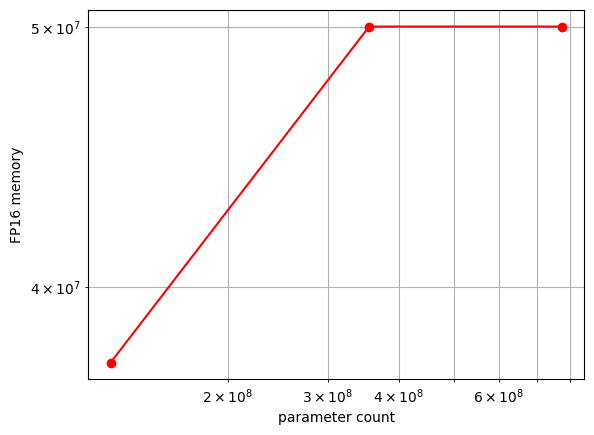

In [81]:
import matplotlib.pyplot as plt

parameter_count_for_small = 124439808
parameter_count_for_medium = 354823168
parameter_count_for_large: 773903616

parameter_count_array_for_models = [124439808,354823168,773903616]

fp_16_memory_for_models = [37500000.0,50000000.0,50000000.0]

plt.plot(parameter_count_array_for_models, fp_16_memory_for_models, 'ro-')

# Convert both axes to log scale
plt.xscale('log')
plt.yscale('log')
plt.xlabel("parameter count")
plt.ylabel("FP16 memory")

plt.grid(True, which="both")
plt.show()


**Analysis :** Why does the Medium model use ~2.9× the memory of Small, but Large only uses ~2.2× the memory of Medium, despite both adding 12 layers


**Analysis Comments:**
The non-linear memory scaling between model sizes happens because embedding layers occupy a fixed amount of memory, while transformer blocks scale quadratically with the hidden dimension dmodel

When you add layers, you are not just adding depth L you are also increasing width dmodel and attention heads.

**Small to Medium (~2.9× memory increase)**

*   Number of Layeres(L) increases from 12 to 24 (2.0× depth).
*   dmodel increases from 768 to 1024 (1.33× width).

Because transformer layer memory scales with the square of the width (dmodel^2), each Medium layer is roughly 1.78× larger than a Small layer.Combining 2.0× depth with 1.78× layer size creates a massive jump in transformer block memory, easily overpowering the static embedding overhead.

**Medium to Large (~2.2× memory increase):**


*   Number of Layeres (L) increases from 24 to 32 (1.33× depth)
*   dmodel increases from 1024 to 1280
*   Each Large layer is roughly 1.56× larger than a Medium layer

The relative jump in both depth (1.33× vs 2.0×) and width (1.25× vs 1.33×) is significantly smaller than the jump from Small to Medium.
